#  PEC with TREX

[Probabilistic error cancellation (PEC)](https://arxiv.org/pdf/1612.02058) is a technique for mitigating quantum noise in observable expectation value calculations. It lets you compute an unbiased estimate of the expectation values. This techique works by executing an ensemble of noisy circuits injected with the inverse of a learned noise model. The noise model is then approximated to a Pauli channel by using Pauli twirling (also known as [randomized compiling](https://journals.aps.org/pra/abstract/10.1103/PhysRevA.94.052325)). Such noise models can be learned efficiently and can be mitigated by using PEC (see [Probabilistic error cancellation with sparse Pauli-Lindblad models on noisy quantum
processors](https://arxiv.org/pdf/2201.09866) for more details).

<img src="../images/pec.png" width="800"/>

[Twirled Readout Error eXtinction (TREX)](https://arxiv.org/pdf/2012.09738) is a technique that mitigates measurement errors and is useful for estimating Pauli observable expectation values. It relies on measurement twirling (randomly injecting an `X` gate before the measurement and flipping the measured result), which diagonalizes the readout-error transfer matrix and makes it easy to invert. A rescaling term is learned from the diagonal noise channel by measuring twirled calibration circuits that were initialized in the zero state.

<img src="../images/measurement_twirling.png" width="300"/>

This guide shows how to use PEC to mitigate gates noise and combine it with TREX to also mitigate measurement noise when estimating observables' expectation values.

The workflow follows:
1. Specify a circuit and observable.
2. Compute exact expectation values by using Qiskit's statevector simulator.
3. Compute noisy, unmitigated expectation values.
4. Learn the entangling layers' noise by using qiskit-noise-learning.
5. Prepare a PEC + TREX program and add a TREX calibration circuit to it.
6. Compare the mitigated expectation values.

### Specify a circuit and observable

Prepare a mirror circuit of a Trotterized time evolution of a linear transverse-field Ising model on eight qubits. Mirror the circuit to cancel the circuit unitary and form an identity circuit. This lets you easily compute each observable's ideal expectation value. In addition, mirroring doubles the circuit depth, which in turn doubles the noise's effect. 

Use the angle $\theta= \frac{\pi}{2}$ to keep all the gates in the circuit from the Clifford group, allowing faster simulation by using the `stabilizer` simulator.

Visualization of 1 mirrored Trotter step


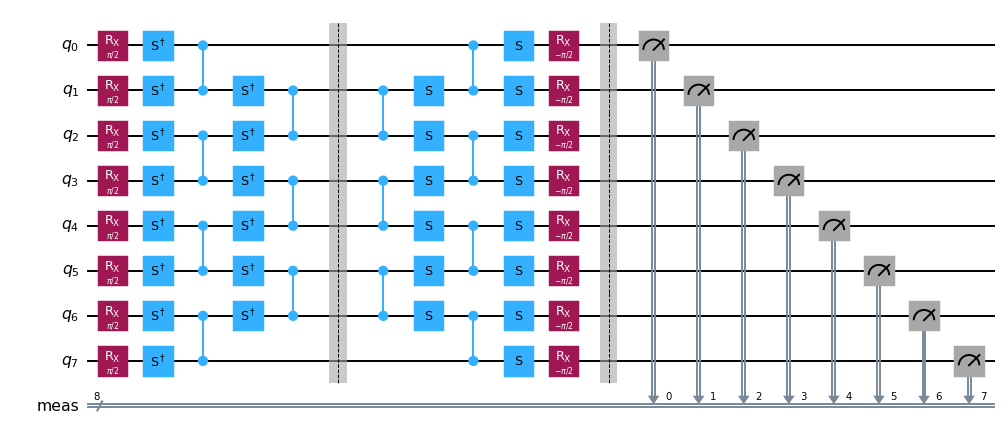

In [1]:
import warnings

import numpy as np
from qiskit.circuit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp

warnings.filterwarnings("ignore")


def construct_ising_circuit(
    num_qubits: int, num_trotter_steps: int, rx_angle: float, barrier: bool = True
) -> QuantumCircuit:
    circuit = QuantumCircuit(num_qubits)

    for _step in range(num_trotter_steps):
        circuit.rx(rx_angle, range(num_qubits))
        if barrier:
            circuit.barrier()
        for first_qubit in (1, 2):
            for idx in range(first_qubit, num_qubits, 2):
                # equivalent to Rzz(-pi/2):
                circuit.sdg([idx - 1, idx])
                circuit.cz(idx - 1, idx)
        if barrier:
            circuit.barrier()

    return circuit


def mirror_circuit(circuit: QuantumCircuit) -> QuantumCircuit:
    mirror_circ = circuit.copy_empty_like()
    mirror_circ.compose(circuit, inplace=True)
    mirror_circ.barrier()
    mirror_circ.compose(circuit.inverse(), inplace=True)
    mirror_circ.measure_active()
    return mirror_circ


# define observables
num_qubits = 8
observables = [
    SparsePauliOp("I" * ((num_qubits - 1) - q) + "Z" + "I" * q) for q in range(num_qubits)
]

# Instantiate circuit
num_trotter_steps = 5
rx_angle = np.pi / 2

circuit = construct_ising_circuit(num_qubits, num_trotter_steps, rx_angle, barrier=False)
mirrored_circuit = mirror_circuit(circuit)
print("Visualization of 1 mirrored Trotter step")
mirror_circuit(construct_ising_circuit(num_qubits, 1, rx_angle, barrier=False)).draw(
    "mpl", scale=0.7
)

### Compute noisy, unmitigated expectation values

A [`QuantumProgram`](https://quantum.cloud.ibm.com/docs/guides/executor-input-output#inputs-quantum-programs) contains a quantum circuit and a [samplex](https://qiskit.github.io/samplomatic/guides/samplex_io.html) in a format suitable for the [Executor](https://quantum.cloud.ibm.com/docs/en/guides/get-started-with-executor) primitive. `MitigationTask.prepare` builds a `QuantumProgram` from the circuit, the observables and the parameter values, and boxes the circuit with the given boxing options. Set the ``measure_annotations`` boxing option to ``"change_basis"`` to rotate the measurements into the required bases, and add ``add_tags: "unique_box"`` so the simulator can map a noise model onto the circuit's boxes. The program is Pauli twirled by default, which on hardware turns coherent noise into the Pauli noise that the mitigation methods assume. `num_randomizations` sets how many twirled instances of each circuit are sampled and `shots_per_randomization` sets how many shots each instance receives, so their product is the shot limit per circuit.

If you have QPU access, you can execute the program with an `Executor` built from a backend of the `QiskitRuntimeService`.  This examples uses an `AerSimulator` to run the program locally. Its `layer_noise_model` simulator option injects a random Pauli-Lindblad noise model on every layer of entangling gates, generated with `random_pauli_lindblad_noise` from `qiskit-mitigation` with an error per layered gate (EPLG) of ``0.003``, typical of current Heron QPUs.

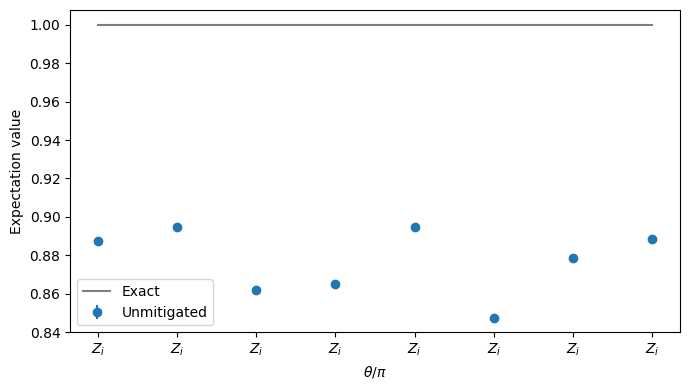

In [2]:
import matplotlib.pyplot as plt
from qiskit.circuit import CircuitInstruction
from qiskit.quantum_info import PauliLindbladMap, pauli_basis
from qiskit.transpiler import PassManager
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import Executor
from qiskit_mitigation import MitigationTask, find_combined_unique_layers
from qiskit_noise_learning.aer_executor.insert_noise_pass import InsertNoisePass
from samplomatic import Tag
from samplomatic.utils import get_annotation


def generate_random_pauli_lindblad_noise(
    layers,
    num_qubits: int,
    eplg: float = 3e-3,
    readout_noise_scale: float = 3e-2,
    seed: int | None = None,
) -> tuple[list[tuple[CircuitInstruction, PauliLindbladMap]], PauliLindbladMap]:
    """Generate random Pauli-Lindblad noise over the full Pauli basis."""
    layer_noise_model = []
    for layer in layers:
        layer_instructions = layer.operation.params[0]
        contain_measurement = any(inst.name.startswith("measure") for inst in layer_instructions)
        if not contain_measurement:
            edges = [
                (inst.qubits[0]._index, inst.qubits[1]._index) for inst in layer_instructions
            ]  # extract the edges of the layer

            basis_paulis = [p for p in pauli_basis(2) if np.sum(p.x + p.z)]
            rng = np.random.default_rng(seed=seed)
            num_generators = len(basis_paulis)
            rates = rng.random(len(basis_paulis)) * eplg / num_generators

            layer_noise = PauliLindbladMap.from_sparse_list(
                [
                    (pauli.to_label(), edge, rate)
                    for pauli, rate in zip(basis_paulis, rates, strict=True)
                    for edge in edges
                ],
                num_qubits=num_qubits,
            )
            layer_noise_model.append((layer, layer_noise))
    # generate a readout noise model
    rng = np.random.default_rng(seed=seed)
    rates = rng.random(num_qubits) * readout_noise_scale
    readout_noise_model = PauliLindbladMap.from_sparse_list(
        [("X", [q], rate) for q, rate in enumerate(rates)],
        num_qubits=num_qubits,
    )
    return layer_noise_model, readout_noise_model


def add_readout_noise(program, readout_noise_model):
    """Injects readout noise to the circuits in a quantum program."""
    readout_noise_map = {}
    for item in program.items:
        readout_tag = item.circuit[-1].label[-4:]  # extract the readout layer tag from the circuit
        readout_noise_map[readout_tag] = readout_noise_model
        item.circuit = PassManager(
            [InsertNoisePass(noise_dict=readout_noise_map, noise_after=False)]
        ).run(item.circuit)


num_randomizations = 300
shots_per_randomization = 64

boxing_options = {"add_tags": "unique_box"}

# find the unique layers to generate the layered noise for
box_layers = find_combined_unique_layers([mirrored_circuit], custom_boxing_options=boxing_options)
layer_noise_model, readout_noise_model = generate_random_pauli_lindblad_noise(
    box_layers, num_qubits, seed=42
)

# a local noisy simulator in place of a QPU backend
noisy_executor = Executor(
    AerSimulator(method="stabilizer"),
    options={"simulator": {"layer_noise_model": layer_noise_model}},
)

task = MitigationTask()
program = task.prepare(
    circuit=mirrored_circuit,
    observables=observables,
    parameters=None,
    num_randomizations=num_randomizations,
    shots_per_randomization=shots_per_randomization,
    custom_boxing_options=boxing_options,
)
# For the simulation - we inject readout noise to the circuits of the program
add_readout_noise(program, readout_noise_model)

program._semantic_role = "simulation"  # flag the program for the simulator
unmitigated_res = task.postprocess(noisy_executor.run(program).result())

x_vals = np.array(range(num_qubits))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_vals, [1] * len(x_vals), "k-", alpha=0.5, label="Exact")
ax.errorbar(
    x_vals,
    unmitigated_res.data.evs,
    unmitigated_res.data.stds,
    fmt="o",
    label="Unmitigated",
)

x_tick_labels = [r"$Z_{ {i} }$" for i in range(num_qubits)]
ax.set_xlabel(r"$\theta/\pi$")
ax.set_ylabel("Expectation value")
ax.legend()
ax.set_xticks(x_vals, x_tick_labels)
plt.tight_layout()
plt.show()

### Learn the entangling layers' noise

PEC starts by learning the twirled noise model of each layer of entangling gates in the circuit. If you assume a Markovian noise model, the depth of the circuit is assumed to not affect the noise channel of a given entangling layer.  Therefore, only the noise model of each unique layer of entangling gates should be learned. The circuit used in this guide can be split into two unique layers. Designing circuits to have a minimal set of unique entangling layers is important if you want to learn a noise model, since the unique layers must be learned independently. If you have too many unique layers in your circuit, noise learning can become infeasible due to the sampling cost of learning many layers.

`qiskit-noise-learning` is used to learn the noise. The learner repeats each layer _`fragment_depths`_ times in its learning circuits, twirls each circuit _`num_randomizations`_ times, and fits the decay of the measured fidelities to a Pauli-Lindblad model. These parameters can effect the accuracy of the learned model. The more accurate the learned noise model is, the more accurate the noise cancellation will be.
The following code draws the learned noise model with the two layers merged into one map. Each qubit is a pie of its weight-1 X, Y and Z rates summed over the two layers, and each edge shows the learned weight-2 rates. For example, a rate of ``3e-4`` means that error occurs on roughly three of every 10,000 uses of the layer.

Readout noise mitigation is done in post-processing by using TREX, as opposed to the **gate** noise model, which is required for the program preperation in order to inject the anti-noise that corresponds to the learned noise model.
Therefore, the readout noise can be either executed and learned when learning the gates' noise, or when executing the mitigated program. Learning the readout noise alongside the gate noise might be beneficial for learning a self-consistent noise model (see [Disambiguating Pauli noise in quantum computers](https://arxiv.org/pdf/2505.22629) for example). In cases where the gate noise and the readout noise are separated in the noise model, it is recommended that you learn the readout noise when executing the mitigated program to avoid drift in the noise between the when it was learned and executed. 

In this guide, the readout noise is learned while executing the mitigated program by using TREX calibration circuit.

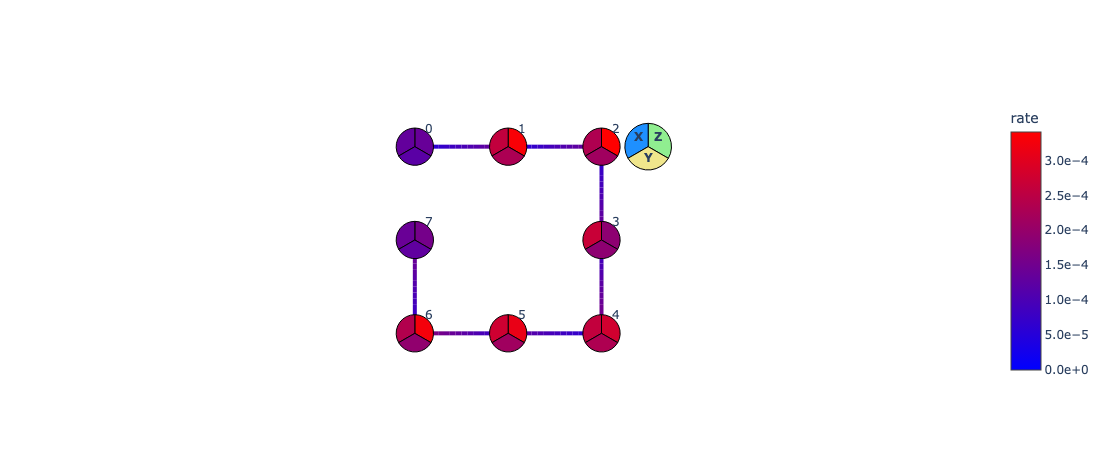

In [3]:
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.quantum_info import PauliList
from qiskit_ibm_runtime.results import LayerError, PauliLindbladError
from qiskit_ibm_runtime.visualization.embeddings import Embedding
from qiskit_mitigation import PEC
from qiskit_noise_learning.aer_executor import AerExecutor
from qiskit_noise_learning.noise_learner import LearningOptions, NoiseLearner
from samplomatic import InjectNoise

line_coupling = [(i, i + 1) for i in range(num_qubits - 1)]
backend = GenericBackendV2(
    num_qubits=num_qubits, basis_gates=["id", "rz", "sx", "x", "cz"], coupling_map=line_coupling
)

task_pec = PEC()
# first learn only the layers PEC will inject noise into, i.e. not the measurement layer
pec_layers = [
    layer
    for layer in task_pec.find_unique_layers(mirrored_circuit, boxing_options)
    if get_annotation(layer.operation, InjectNoise)
]
layers = task_pec.find_unique_layers(mirrored_circuit, boxing_options)

learning_options = LearningOptions(
    fragment_depths=[2, 4, 8, 16], num_randomizations=250, shots_per_randomizations=16
)

# qiskit-noise-learning is not compatible with the Executor in local mode,
# and requires the simulator present in the package for running simulation
noise_dict = {
    get_annotation(layer.operation, Tag).ref: noise_layer
    for layer, noise_layer in layer_noise_model
}
noise_learner_simulator = AerExecutor(
    qasm_simulator=AerSimulator(method="stabilizer"), noise_dict=noise_dict
)
learner = NoiseLearner(backend, options=learning_options, executor=noise_learner_simulator)
learned_noise = learner.run(pec_layers).result().to_dict()  # keyed by InjectNoise reference

# Draw the learned model on the line, laid out as a line with the qubits in order.
# Composing the two layers' maps sums their rates, giving one map over all the edges.
embedding = Embedding(
    [(0, 0), (0, 2), (0, 4), (2, 4), (4, 4), (4, 2), (4, 0), (2, 0)], line_coupling
)
first, second = learned_noise.values()
learned_model = first.compose(second).simplify()
error = PauliLindbladError(
    PauliList(learned_model.get_qubit_sparse_pauli_list_copy().to_pauli_list()), learned_model.rates
)
fig = LayerError(circuit, list(range(num_qubits)), error).draw_map(
    embedding, radius=0.4, height=460, width=620
)
fig.update_traces(
    marker={
        "cmin": 0,
        "cmax": max(learned_model.rates),
        "colorbar": {"tickformat": ".1e", "title": "rate"},
    },
    selector={"mode": "markers"},
)
fig.show()

### Prepare a combined PEC and TREX program

Here we prepare both a `TREX` and a `PEC` task, and add the `TREX` task as a variable to the `PEC` task. This ensures that all the reiquired properties needed for TREX mitigation are added to the PEC mitigated item (like measurement twirling). The injected noise is sampled once per randomization, so the statistical error of PEC is controlled by the number of randomizations rather than the shots per randomization. Thus, many randomizations are used - each with few shots - keeping the total number of shots the same as for the unmitigated program.

The TREX calibration circuit is added to the program in order to learn the readout noise while executing the program. The TREX calibration circuit is very shallow, which makes additional randomizations for it to be relatively cheap and allows the readout noise to be learned more accurately.

In [4]:
from qiskit_mitigation import TREX

trex = TREX()

program_pec = task_pec.prepare(
    circuit=mirrored_circuit,
    observables=observables,
    parameters=None,
    num_randomizations=1200,
    shots_per_randomization=16,
    custom_boxing_options=boxing_options,
    trex=trex,
    noise_maps=learned_noise,  # PEC option
    noise_gain=0,  # PEC option
    max_sampling_overhead=100,  # PEC option
)
program_pec = trex.prepare(
    num_randomizations=1500, quantum_program=program_pec, custom_boxing_options=boxing_options
)

# For the simulation - we inject readout noise to the circuits of the program
add_readout_noise(program_pec, readout_noise_model)

### Examine shot overhead, execute the program, and post-process

PEC returns an unbiased expectation value estimation, with a cost of large shot overhead. The required shot overhead can be approximated by calculating the circuit gamma factor, which reflects the effect of the learned noise model on the circuit. By default, the number of randomization of the PEC task is scaled by the approximate amount of shot overheaed required to have an unbiased estimation (~$\gamma^2$). To avoid this automatic scale, you can set the parameter `scale_randomizations_by_gamma` to `False`. The shots overhead is capped by the `max_sampling_overhead` parameter.

You should review the number of shots required by PEC to reach unbiased estimation before execution to decide whether this amount is affordable, as this scales exponentially in the noise rates and circuit depth.

In [5]:
print(f"The circuit calculated gamma is: {task_pec.gamma}")
print(f"The circuit shot overhead is ~{task_pec.gamma**2}")

The circuit calculated gamma is: 1.2774846896089953
The circuit shot overhead is ~1.631967132185391


In [6]:
program_pec._semantic_role = "simulation"  # flag the program for the simulator
job_pec_results = noisy_executor.run(program_pec).result()

# post-processing
pec_res = task_pec.postprocess(job_pec_results)
# In order to post process the results without TREX, we call `postprocess` again, but instead of the default options we
# pass only the PEC item result and the `measure_noise_data` as `None`
pec_without_trex_res = task_pec.postprocess(
    job_pec_results[task_pec._program_item_index], measure_noise_data=None
)

### Compare the mitigated expectation values

Finally, plot the expectation value of each observable. PEC + TREX recovers the exact expectation values within its error bars, while the unmitigated result is biased well below it.

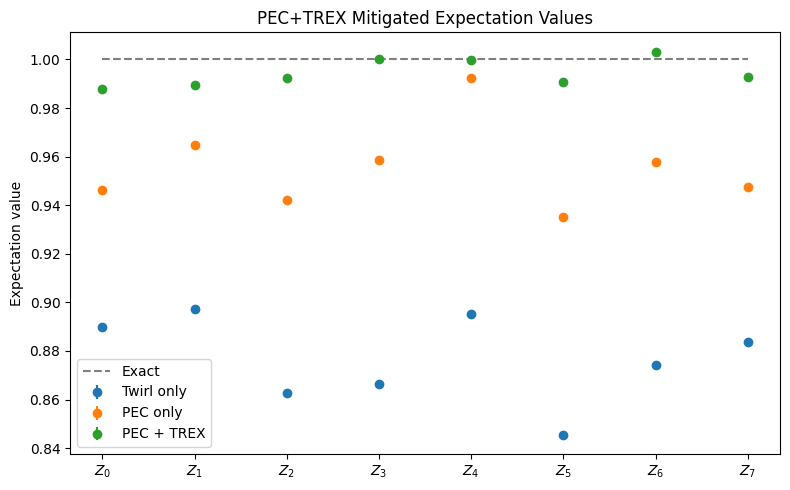

In [7]:
x = np.array(range(num_qubits))
x_tick_labels = [r"$Z_{ {i} }$" for i in range(num_qubits)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(
    x,
    unmitigated_res.data.evs,
    unmitigated_res.data.stds,
    fmt="o",
    label="Twirl only",
)
ax.errorbar(
    x,
    pec_without_trex_res.data.evs,
    pec_without_trex_res.data.stds,
    fmt="o",
    label="PEC only",
)
ax.errorbar(
    x,
    pec_res.data.evs,
    pec_res.data.stds,
    fmt="o",
    label="PEC + TREX",
)

ax.plot(x, [1] * len(x), "--", color="black", alpha=0.5, label="Exact")

tick_labels = [f"$Z_{ {i} }$" for i in range(num_qubits)]
ax.set_xticks(x, tick_labels)

ax.set_ylabel("Expectation value")
ax.legend()
ax.set_title("PEC+TREX Mitigated Expectation Values")
plt.tight_layout()
plt.show()